In [1]:
import numpy as np
import scipy.ndimage as nd
from skimage import data, morphology, filters as imfilter
import cv2
import matplotlib.pyplot as plt
import skimage.metrics as metrics
cv2.useOptimized() 
import urllib.request

Text(0.5, 1.0, 'Grayscale Image')

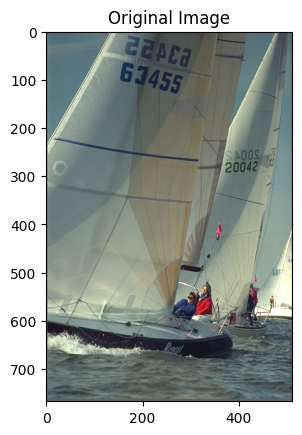

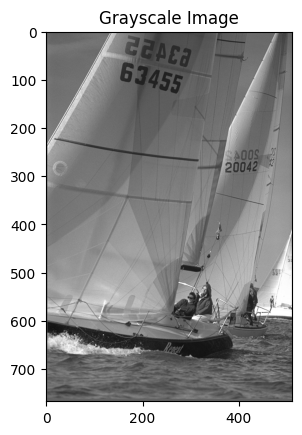

In [2]:
# read samle image from url
urllib.request.urlretrieve('https://r0k.us/graphics/kodak/kodak/kodim10.png', 'kodim10.png')
im=cv2.imread('kodim10.png')
im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
imgray=cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)

plt.figure()
plt.imshow(im)
plt.title('Original Image')

plt.figure()
plt.imshow(imgray, cmap='gray')
plt.title('Grayscale Image')

Text(0.5, 1.0, 'Mean Filtered Image')

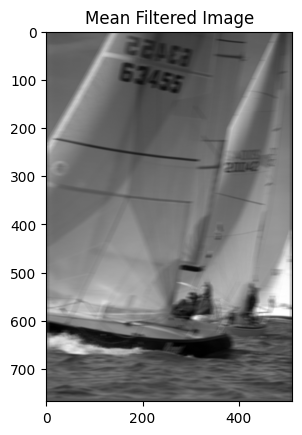

In [4]:
#spatial filtering
#mean filter
kernel_size = (3,13)
mean_filter = np.ones(kernel_size, np.float32)/(kernel_size[0]*kernel_size[1])
mean_filtered = cv2.filter2D(imgray, ddepth=cv2.CV_32F, kernel=mean_filter)

plt.figure()
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filtered Image')


In [5]:
def dft_filter(im, kernel, debug=False):
    #pad the kernel to the size of the image
    kernel_padded = np.zeros(im.shape)
    rows, cols = im.shape
    rk, ck = kernel.shape
    kernel_padded[rows//2-rk//2:rows//2+rk//2+1, cols//2-ck//2:cols//2+ck//2+1] = kernel
    kernel_padded=np.fft.ifftshift(kernel_padded)
    #kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel
    #compute the DFT of the image and the kernel
    im_dft = np.fft.fft2(im)
    kernel_dft = np.fft.fft2(kernel_padded)
    #compute the product of the DFT of the image and the DFT of the kernel
    im_filtered_dft = im_dft*kernel_dft
    #compute the inverse DFT of the product
    im_filtered = np.fft.ifft2(im_filtered_dft)
    im_filtered = np.abs(im_filtered)
    #return the real part of the result

    if debug:
        #plt.figure()
        ax = plt.figure().add_subplot(projection='3d')
        #plt.pcolormesh(np.fft.fftshift(np.log(1+np.abs(kernel_dft))))
        X,Y = np.meshgrid(np.arange(0,im.shape[1]),np.arange(0,im.shape[0]))
        ax.plot_surface(X,Y, 
                        np.fft.fftshift(np.log(1+np.abs(kernel_dft))), cmap='viridis')
        plt.title('Kernel DFT')
        #plt.colorbar()
    return np.real(im_filtered)


def inv_dft_filter(im, kernel,eps=1e-12,debug=False):
    #pad the kernel to the size of the image
    kernel_padded = np.zeros(im.shape)
    rows, cols = im.shape
    rk, ck = kernel.shape
    kernel_padded[rows//2-rk//2:rows//2+rk//2+1, cols//2-ck//2:cols//2+ck//2+1] = kernel
    kernel_padded=np.fft.ifftshift(kernel_padded)
    #kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel
    #compute the DFT of the image and the kernel
    im_dft = np.fft.fft2(im)
    kernel_dft = np.fft.fft2(kernel_padded)
    #compute the product of the DFT of the image and the DFT of the kernel
    kernel_dft[np.abs(kernel_dft) < eps] = 1.0
    im_filtered_dft = im_dft/(kernel_dft)
    #compute the inverse DFT 
    im_filtered = np.fft.ifft2(im_filtered_dft)
    im_filtered = np.abs(im_filtered)

    if debug:
        #plt.figure()
        ax = plt.figure().add_subplot(projection='3d')
        #plt.pcolormesh(np.fft.fftshift(np.log(1+np.abs(kernel_dft))))
        X,Y = np.meshgrid(np.arange(0,im.shape[1]),np.arange(0,im.shape[0]))
        ax.plot_surface(X,Y, 
                        np.fft.fftshift(np.log(1+np.abs(1/kernel_dft))), cmap='viridis')
        plt.title('Iverse Kernel DFT')
        #plt.colorbar()

    #return the real part of the result
    return np.real(im_filtered)

def psnr(im1,im2):
    p=-1.0
    assert im1.shape == im2.shape
    p=255**2/np.mean((im1-im2)**2)
    p=10*np.log10(p)
    return p

Degradated PSNR : 25.650084 dB
Restored PSNR : 26.93303365848682 dB


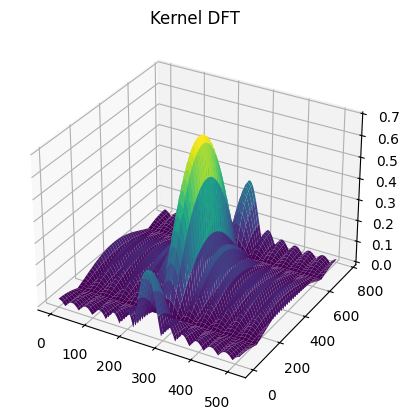

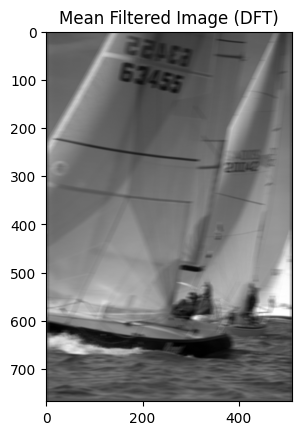

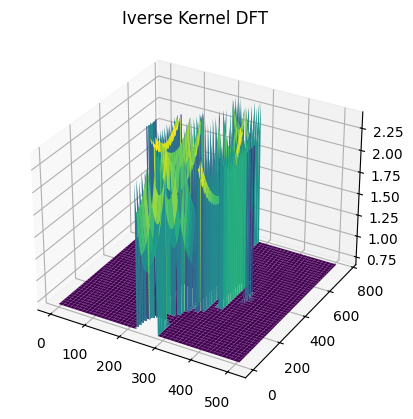

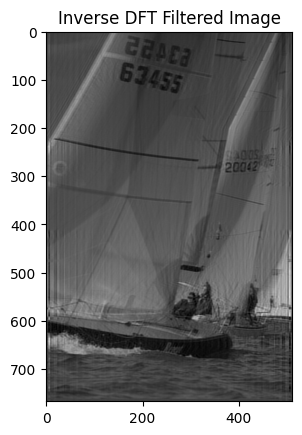

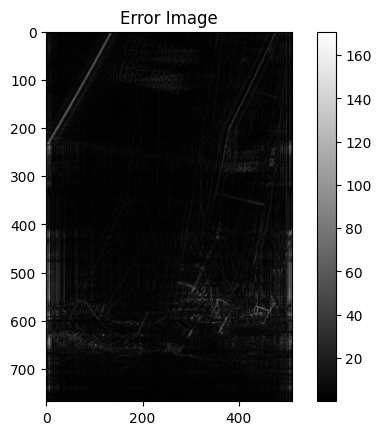

In [6]:
mean_filtered_dft = dft_filter(imgray, mean_filter,debug=True)

plt.figure()    
plt.imshow(mean_filtered_dft, cmap='gray')
plt.title('Mean Filtered Image (DFT)')

#err_img=np.abs( mean_filtered_dft-mean_filtered)
#plt.figure()
#plt.imshow(np.log10(err_img), cmap='gray')
#plt.title('Error Image')
#plt.colorbar()
#print('Mean Absolute Error:',np.sqrt( np.mean(err_img**2)))

inv_dft_filtered = inv_dft_filter(mean_filtered, mean_filter,eps=0.1,debug=True)
#inv_dft_filtered = inv_dft_filter(mean_filtered_dft, mean_filter)


    

plt.figure()
plt.imshow(inv_dft_filtered, cmap='gray')
plt.title('Inverse DFT Filtered Image')

err_img=np.abs( imgray-inv_dft_filtered)
plt.figure()
plt.imshow(err_img, cmap='gray')
plt.title('Error Image')
plt.colorbar()
print('Degradated PSNR :',psnr(imgray,mean_filtered) , 'dB')
print('Restored PSNR :',psnr(imgray,inv_dft_filtered) , 'dB')

In [7]:
#wiener filter
def wiener_filter(im, kernel, K=0.01,debug=False):
    #pad the kernel to the size of the image
    kernel_padded = np.zeros(im.shape)
    rows, cols = im.shape
    rk, ck = kernel.shape
    kernel_padded[rows//2-rk//2:rows//2+rk//2+1, cols//2-ck//2:cols//2+ck//2+1] = kernel
    kernel_padded=np.fft.ifftshift(kernel_padded)
    #kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel
    #compute the DFT of the image and the kernel
    im_dft = np.fft.fft2(im)
    kernel_dft = np.fft.fft2(kernel_padded)
    #compute the product of the DFT of the image and the DFT of the kernel
    H = np.conj(kernel_dft)/(np.abs(kernel_dft)**2+K)
    im_filtered_dft = H*im_dft
    #compute the inverse DFT of the product
    im_filtered = np.fft.ifft2(im_filtered_dft)
    im_filtered = np.abs(im_filtered)

    if debug:
        #plt.figure()
        ax = plt.figure().add_subplot(projection='3d')
        #plt.pcolormesh(np.fft.fftshift(np.log(1+np.abs(kernel_dft))))
        X,Y = np.meshgrid(np.arange(0,im.shape[1]),np.arange(0,im.shape[0]))
        ax.plot_surface(X,Y, 
                        np.fft.fftshift(np.log(1+np.abs(H))), cmap='viridis')
        plt.title('Wiener Kernel DFT')
    #return the real part of the result
    return np.real(im_filtered)

Wiener Filtered PSNR : 28.03347953253088 dB


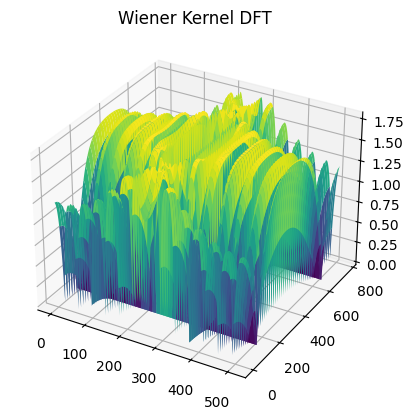

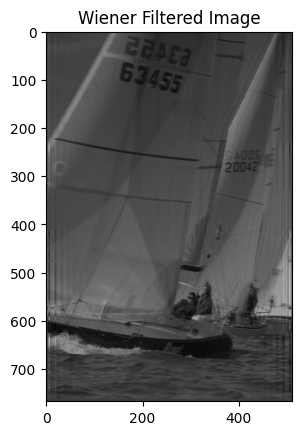

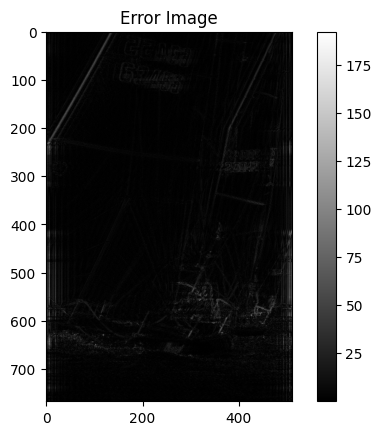

In [8]:
wiener_filtered = wiener_filter(mean_filtered, mean_filter, K=0.01,debug=True)

plt.figure()
plt.imshow(wiener_filtered, cmap='gray')
plt.title('Wiener Filtered Image')

err_img=np.abs( wiener_filtered-imgray)
plt.figure()

plt.imshow(err_img, cmap='gray')
plt.title('Error Image')
plt.colorbar()

print('Wiener Filtered PSNR :',psnr(imgray,wiener_filtered) , 'dB')
